# Adsorption Using AiiDAlab

### Group L : Taïs Thomas, Marouchka Heck, Marie-Caroline Bilocq

### 1. Describe the type of calculations AiiDAlab offers for adsorption studies

AiiDAlab offers three main types of calculations for adsorption studies:

**Pore analysis**

Pore analysis characterizes the pore structure of the material using a probe molecule. It provides geometrical properties such as the **accessible surface area (ASA)**, **probe-occupiable volume (POAV)**, and **porosity**.

**Henry coefficient calculation**

The Henry coefficient describes adsorption in the **low-pressure limit** and provides information about the affinity of a gas for the adsorbent. It can therefore be used to compare the adsorption behavior of different gases.

**Adsorption isotherm calculation**

An adsorption isotherm gives the **amount of gas adsorbed as a function of pressure at a fixed temperature**. It allows the adsorption capacity of the material to be evaluated over a range of pressures.

### 2. Compute the density ($\mathrm{g \cdot cm^{-3}}$), accessible surface area – ASA ($\mathrm{\mathring{A}^2}$), accessible probe-occupiable volume – POAV ($\mathrm{\mathring{A}^3}$), and porosity of the material (probe radius: $1.525\ \mathrm{\mathring{A}}$)

Using a probe radius of $1.525\ \mathrm{\mathring{A}}$, the pore analysis of IRMOF-1 gives:

| Property | Value |
|---|---:|
| Density | $0.576983\ \mathrm{g \cdot cm^{-3}}$ |
| Accessible surface area (ASA) | $3964.65\ \mathrm{\mathring{A}^2}$ |
| Probe-occupiable volume (POAV) | $13737.4\ \mathrm{\mathring{A}^3}$ |
| Porosity | $0.77498$ ($77.498\%$) |

### 3. Compute the Henry coefficients for $CO_2$ and $CH_4$ at $300\ \mathrm{K}$. What can you deduce?

At $300\ \mathrm{K}$, the Henry coefficients obtained for $CO_2$ and $CH_4$ are:

$$
K_H(\mathrm{CO_2}) = 4.95279 \times 10^{-6}\ \mathrm{mol \cdot kg^{-1} \cdot Pa^{-1}}
$$

$$
K_H(\mathrm{CH_4}) = 1.12115 \times 10^{-6}\ \mathrm{mol \cdot kg^{-1} \cdot Pa^{-1}}
$$

The Henry coefficient of $CO_2$ is therefore approximately:

$$
\frac{K_H(\mathrm{CO_2})}{K_H(\mathrm{CH_4})}
=
\frac{4.95279 \times 10^{-6}}{1.12115 \times 10^{-6}}
\approx 4.42
$$

Thus, at low pressure, IRMOF-1 has a higher affinity for $CO_2$ than for $CH_4$, since the Henry coefficient of $CO_2$ is about $4.4$ times larger than that of $CH_4$.

### 4. Compute the pure $CO_2$ and $CH_4$ adsorption isotherms at $300\ \mathrm{K}$ and plots of the results.

In [128]:
co2_output = pd.read_csv("871.csv")

co2_output.head()

,Key,Value
0,Density,0.576983
1,Density_unit,g/cm^3
2,Estimated_saturation_loading,26.78196
3,Estimated_saturation_loading_unit,mol/kg
4,Input_block,"[1.525, 100]"


In [129]:
import ast

co2_isotherm_data = ast.literal_eval(
    co2_output.loc[co2_output["Key"] == "isotherm", "Value"].iloc[0]
)

In [130]:
co2_pressure = co2_isotherm_data["pressure"]
co2_loading = co2_isotherm_data["loading_absolute_average"]

In [131]:
ch4_output = pd.read_csv("417.csv")

In [132]:
ch4_isotherm_data = ast.literal_eval(
    ch4_output.loc[ch4_output["Key"] == "isotherm", "Value"].iloc[0]
)

In [133]:
ch4_pressure = ch4_isotherm_data["pressure"]
ch4_loading = ch4_isotherm_data["loading_absolute_average"]

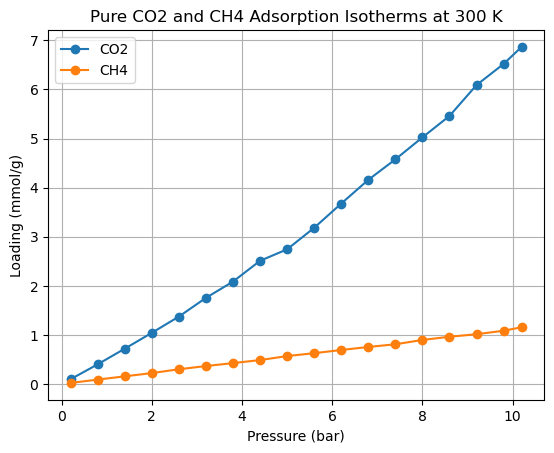

In [134]:
plt.plot(co2_pressure, co2_loading, "o-", label="CO2")
plt.plot(ch4_pressure, ch4_loading, "o-", label="CH4")

plt.xlabel("Pressure (bar)")
plt.ylabel("Loading (mmol/g)")
plt.title("Pure CO2 and CH4 Adsorption Isotherms at 300 K")
plt.legend()
plt.grid()

plt.show()

The pure-component adsorption isotherms at $300\ \mathrm{K}$ show that the loading of both $CO_2$ and $CH_4$ increases with pressure. However, $CO_2$ is adsorbed in significantly larger amounts than $CH_4$ over the entire investigated pressure range.

This indicates a stronger affinity of IRMOF-1 for $CO_2$ than for $CH_4$, which is consistent with the Henry coefficients obtained in Question 3. At low pressure, the larger Henry coefficient of $CO_2$ already indicates stronger $CO_2$ adsorption, and the pure-component isotherms show that this difference persists as the pressure increases.

Neither gas reaches a clear adsorption plateau within the investigated pressure range, although the increase in $CH_4$ loading is considerably smaller than for $CO_2$.

### 5. Use pyIAST to obtain the binary-mixture isotherms by the linear interpolation method for a pressure range from 0.1 to 4.0. Use increments of 0.2 and plot the results.

In [135]:
%pip install pyiast

Note: you may need to restart the kernel to use updated packages.


In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyiast

co2_data = pd.read_csv("871.csv")
ch4_data = pd.read_csv("417.csv")

In [137]:
import ast

co2_isotherm_data = ast.literal_eval(
    co2_data.loc[co2_data["Key"] == "isotherm", "Value"].iloc[0]
)

ch4_isotherm_data = ast.literal_eval(
    ch4_data.loc[ch4_data["Key"] == "isotherm", "Value"].iloc[0]
)

In [138]:
co2_data = pd.DataFrame({
    "Pressure(bar)": co2_isotherm_data["pressure"],
    "Loading(mmol/g)": co2_isotherm_data["loading_absolute_average"]
})

ch4_data = pd.DataFrame({
    "Pressure(bar)": ch4_isotherm_data["pressure"],
    "Loading(mmol/g)": ch4_isotherm_data["loading_absolute_average"]
})

In [139]:
co2_isotherm = pyiast.InterpolatorIsotherm(
    co2_data,
    loading_key="Loading(mmol/g)",
    pressure_key="Pressure(bar)"
)

ch4_isotherm = pyiast.InterpolatorIsotherm(
    ch4_data,
    loading_key="Loading(mmol/g)",
    pressure_key="Pressure(bar)"
)

In [140]:
pressures = np.arange(0.1, 4.01, 0.2)

y_co2 = 0.4
y_ch4 = 0.6

pressures

array([0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7, 1.9, 2.1, 2.3, 2.5,
       2.7, 2.9, 3.1, 3.3, 3.5, 3.7, 3.9])

In [141]:
co2_loading = []
ch4_loading = []

for P in pressures:
    partial_pressures = [y_co2 * P, y_ch4 * P]

    loading = pyiast.iast(
        partial_pressures,
        [co2_isotherm, ch4_isotherm]
    )

    co2_loading.append(loading[0])
    ch4_loading.append(loading[1])

In [142]:
results = pd.DataFrame({
    "Pressure (bar)": pressures,
    "CO2 Loading (mmol/g)": co2_loading,
    "CH4 Loading (mmol/g)": ch4_loading
})

results

,Pressure (bar),CO2 Loading (mmol/g),CH4 Loading (mmol/g)
0,0.1,0.019718,0.006520
1,0.3,0.059267,0.019864
2,0.5,0.099177,0.033402
3,0.7,0.139356,0.046916
4,0.9,0.180099,0.060543
5,1.1,0.221800,0.074792
6,1.3,0.261597,0.088475
7,1.5,0.300998,0.101861
8,1.7,0.341861,0.115494
9,1.9,0.383767,0.129278


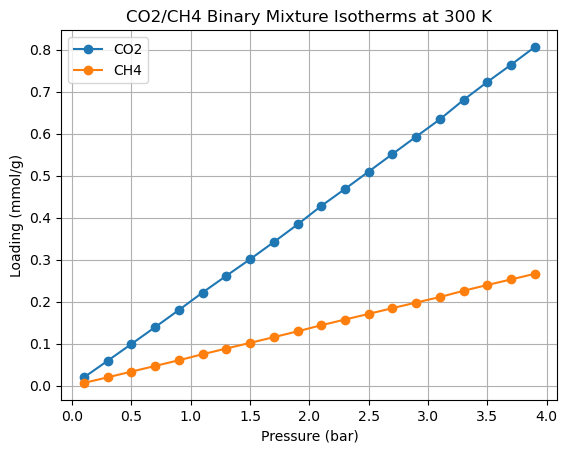

In [143]:
plt.plot(pressures, co2_loading, "o-", label="CO2")
plt.plot(pressures, ch4_loading, "o-", label="CH4")

plt.xlabel("Pressure (bar)")
plt.ylabel("Loading (mmol/g)")
plt.title("CO2/CH4 Binary Mixture Isotherms at 300 K")
plt.legend()
plt.grid()

plt.show()

The binary $CO_2$/$CH_4$ adsorption isotherms were calculated at $300\ \mathrm{K}$ using pyIAST with the linear interpolation method. The gas-phase composition was taken as $y_{\mathrm{CO_2}} = 0.4$ and $y_{\mathrm{CH_4}} = 0.6$.

The results show that the loading of both components increases with pressure. However, the $CO_2$ loading is significantly higher than the $CH_4$ loading, indicating preferential adsorption of $CO_2$ in IRMOF-1.

This observation is also consistent with the Henry coefficients obtained in Question 3, where the Henry coefficient of $CO_2$ was approximately $4.4$ times larger than that of $CH_4$.
Since Henry coefficients describe adsorption in the low-pressure regime, this indicates a stronger affinity of IRMOF-1 for $CO_2$ at low pressure. The binary-mixture isotherms show that the preferential adsorption of $CO_2$ continues as the pressure increases.